<img src="https://github.com/CharleyHananiaGA/DSB-Unit-02/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Handling Missing Data in Python

---

### About
In this notebook, we will explore various techniques for identifying, visualizing, and handling missing data in Python using `pandas` and other libraries. Missing data is a common challenge in real-world data sets, and understanding how to address it effectively is a crucial skill for data analysis.

### Learning Objectives
- Identify and visualize missing data
- Understand patterns of missingness
- Implement deletion methods
- Apply simple imputation techniques
- Evaluate the impact of different approaches

### Notebook Guide
1. Setup and Load Data
2. Identifying Missing Data
3. Deletion Methods
4. Simple Imputation Methods
5. Imputation Based on Other Variables
6. Handling Mixed Data Types
7. Best Practices and Conclusion
8. Now You Try
9. Conclusion

# 1. Setup and Load Data

In [28]:
# !pip install missingno

In [29]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For visualization of missing data
import missingno as msno

# For evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set the random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Let's load a data set with missing values to work with. We'll use a modified version of the Titanic data set.

In [30]:
# Load the Titanic data set
url = "https://raw.githubusercontent.com/CharleyHananiaGA/DSB-Unit-02/refs/heads/main/data/titanic-adj.csv"
titanic_df = pd.read_csv(url)


In [31]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [32]:
titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# 2. Identifying Missing Data

The first step in handling missing data is to identify and understand the extent of missingness in your data set.

In [33]:
# Check for missing values in each column
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [34]:
# Calculate the percentage of missing values in each column
titanic_df.isnull().mean() *100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


### Visualizing Missing Data

Visualization can help identify patterns in missingness. The [`missingno`](https://github.com/ResidentMario/missingno) library is particularly useful for this purpose.

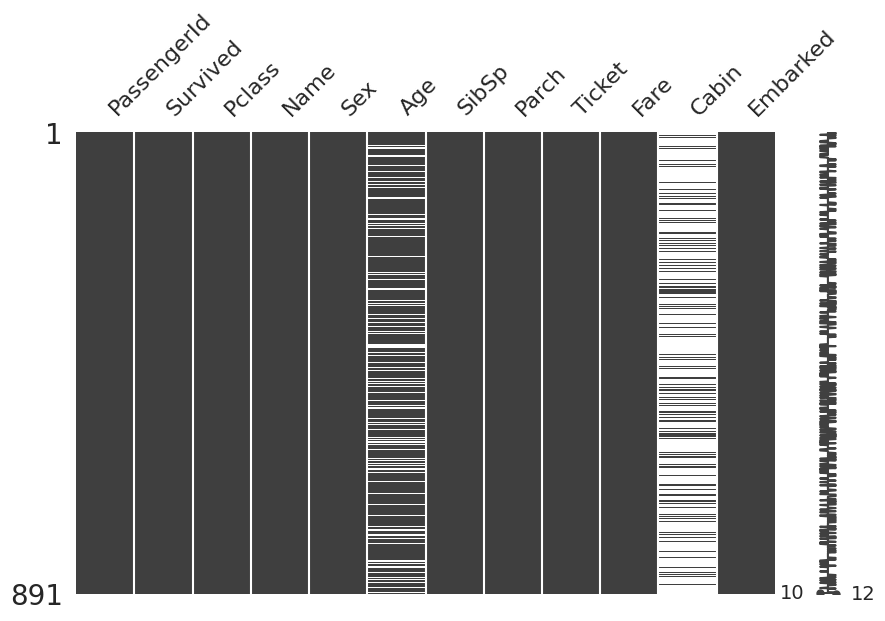

In [35]:
# Create a matrix visualization of missing values
msno.matrix(titanic_df, figsize=(10,6));

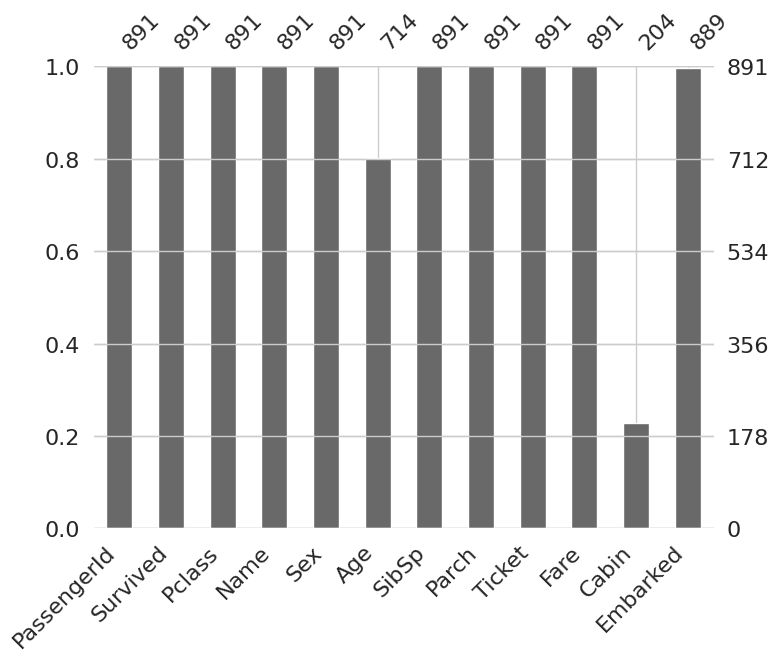

In [36]:
# Create a bar chart showing the count of missing values by column
msno.bar(titanic_df, figsize=(8, 6));

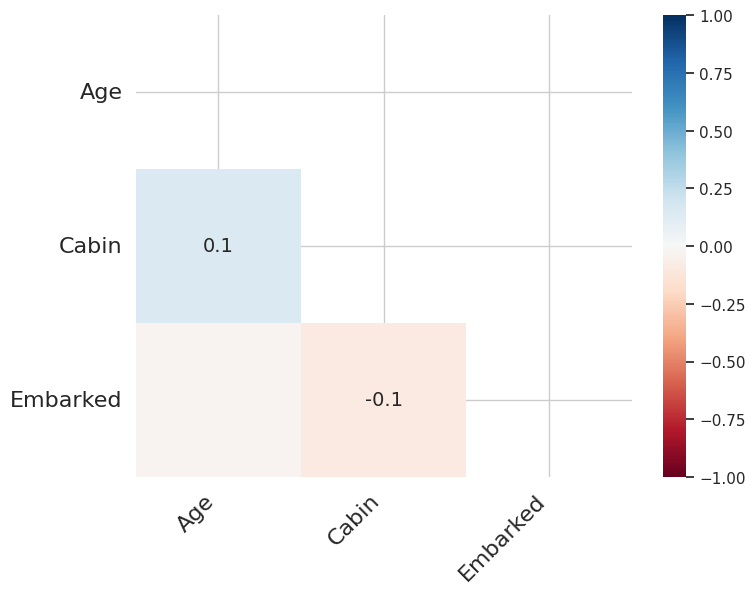

In [37]:
# Create a heatmap to show correlations between missingness
msno.heatmap(titanic_df, figsize=(8,6));

### What patterns of missingness can you see in the Titanic data set? Are there any relationships between missing values in different columns?


There are several patterns of missingness:

1. The `Cabin` column has the highest percentage of missing values (78%), which suggests that cabin information was not recorded for most passengers.
2. `Age` is missing for about 20% of passengers, which is a substantial proportion.
3. `Embarked` has a very small percentage of missing values (0.2%), indicating just a few missing entries.

From the heatmap, there doesn't appear to be a strong correlation between missingness in different columns. This suggests that missingness in one column is not strongly related to missingness in other columns. For example, a passenger with a missing `Age` value is not necessarily more likely to have a missing `Cabin` value.

The lack of strong correlation between missingness patterns could suggest that the data might be **Missing Completely At Random (MCAR)** or **Missing At Random (MAR)**, but we would need _domain knowledge_ to confirm this.

---Back to the slides!---

# 3. Deletion Methods

The simplest approach to handling missing data is to remove observations or variables with missing values.

### 3.1 Listwise Deletion (Complete-case analysis)

In [38]:
# Remove all rows with any missing values
# Check how many rows remain
df_listwise_deleted_titanic = titanic_df.dropna()

df_listwise_deleted_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


In [39]:
print(f"Original Titanic data set size: {len(titanic_df)}")
print(f"listwise Titanic data set size: {len(df_listwise_deleted_titanic)}")
print(f"Percentage of data kept: {len(df_listwise_deleted_titanic) / len(titanic_df) * 100:.2f}")

Original Titanic data set size: 891
listwise Titanic data set size: 183
Percentage of data kept: 20.54


### 3.2 Column Deletion

In [40]:
# Create a copy of the original data set
df_column_deleted_titanic = titanic_df.copy()

# Remove columns with more than 30% missing values
threshold = 0.3
df_column_deleted_titanic = df_column_deleted_titanic.loc[:, df_column_deleted_titanic.isnull().mean() < threshold]

# Print the remaining columns
print(f"Original  Columns: {list(titanic_df.columns)}")
print(f"Remaining Columns: {list(df_column_deleted_titanic.columns)}")


Original  Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Remaining Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


### 3.3 Dropping specific columns

Sometimes, we decide to drop specific columns based on domain knowledge or analysis requirements.

In [41]:
# Drop the 'Cabin' column
df_no_cabin = titanic_df.drop(columns=['Cabin'])
print(f"Original  Columns: {list(titanic_df.columns)}")
print(f"Remaining Columns: {list(df_no_cabin.columns)}")


Original  Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Remaining Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


### 3.4 Dropping specific rows (subset of columns)

In [42]:
# Drop rows where 'Age' is missing, but keep rows with missing values in other columns
df_titanic_age_complete = titanic_df.dropna(subset=['Age'])

# Check how many rows remain
print(f"Original Titanic data set size: {len(titanic_df)}")
print(f"listwise Titanic data set size: {len(df_titanic_age_complete)}")
print(f"Percentage of data kept: {len(df_titanic_age_complete) / len(titanic_df) * 100:.2f}")

Original Titanic data set size: 891
listwise Titanic data set size: 714
Percentage of data kept: 80.13


### What are the advantages and disadvantages of the deletion methods you've implemented above?

**Advantages of deletion methods:**

1. **Simplicity**: Deletion methods are straightforward to understand and implement.
2. **No imputation bias**: By removing missing values rather than imputing them, we avoid introducing potential biases from imputation.
3. **Valid for MCAR data**: If data is Missing Completely At Random, listwise deletion produces unbiased parameter estimates (though with reduced efficiency).
4. **Computational efficiency**: Deletion methods require less computational resources than some imputation techniques.

**Disadvantages of deletion methods:**

1. **Data loss**: As seen in our implementation, listwise deletion resulted in losing about 80% of the data set, which is a significant reduction in sample size.
2. **Statistical power reduction**: Smaller sample sizes lead to reduced statistical power, making it harder to detect significant effects.
3. **Potential bias**: If data is not MCAR, deletion methods can introduce bias in the analysis.
4. **Information loss**: Deleted observations might contain valuable information for other variables that are not missing.
5. **Complete-case analysis bias**: When certain groups or demographics are more likely to have missing data, their underrepresentation in the analysis could lead to skewed results.

**Specific to column deletion:**
- **Loss of potentially important variables**: In the Titanic data set, dropping the 'Cabin' column might eliminate information that could be useful for predicting survival (e.g., cabin location might correlate with survival rates).

**Specific to subset deletion:**
- **Inconsistent sample size**: Using different subsets of the data for different analyses can lead to inconsistencies in results.
- **Selective analysis**: Analyzing only passengers with age information might introduce selection bias if age missingness is related to other variables.

---Back to the slides!---

# 4. Simple Imputation Methods

Instead of deleting data, we can replace missing values with estimates.

### 4.1 Mean/Median/Mode Imputation

In [27]:
# Create a copy of the original data set
df_titanic_imputed = titanic_df.copy()

# Impute missing values in the 'Age' column with the mean
mean_age = df_titanic_imputed['Age'].mean()
df_titanic_imputed['Age'] = df_titanic_imputed['Age'].fillna(mean_age)

# Check that there are no missing values in the 'Age' column
print(f"Missing values in Age column: {df_titanic_imputed['Age'].isnull().sum()}")


Missing values in Age column: 0


In [52]:
# Create a copy of the original data set
df_titanic_imputed_med = titanic_df.copy()

# Impute missing values in the 'Age' column with the median
median_age = df_titanic_imputed_med['Age'].median()
df_titanic_imputed_med['Age'] = df_titanic_imputed_med['Age'].fillna(median_age)

# Check that there are no missing values in the 'Age' column
print(f"Missing values in Age column: {df_titanic_imputed_med['Age'].isnull().sum()}")

Missing values in Age column: 0


In [54]:
# Create a copy of the original data set
df_titanic_imputed_mode = titanic_df.copy()

# Impute missing values in the 'Embarked' column with the mode
mode_embarked = df_titanic_imputed_mode['Embarked'].mode()[0]
df_titanic_imputed_mode['Embarked'] = df_titanic_imputed_mode['Embarked'].fillna(mode_embarked)

# Check that there are no missing values in the 'Embarked' column
print(f"Missing values in Embarked column: {df_titanic_imputed_mode['Embarked'].isnull().sum()}")

Missing values in Embarked column: 0


Let's compare the distribution of `Age` before and after imputation.

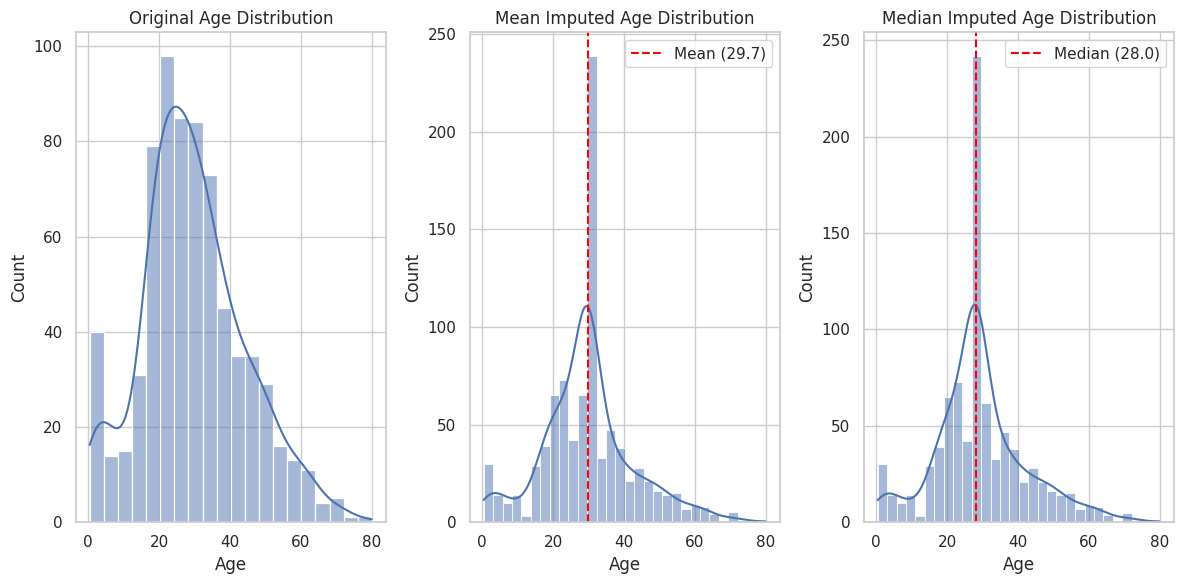

In [55]:
# Compare the original and imputed age distributions
plt.figure(figsize=(12, 6))

# Original age distribution (excluding missing values)
plt.subplot(1, 3, 1)
sns.histplot(titanic_df['Age'].dropna(), kde=True)
plt.title('Original Age Distribution')
plt.xlabel('Age')

# Mean imputed age distribution
plt.subplot(1, 3, 2)
sns.histplot(df_titanic_imputed['Age'], kde=True)
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean ({mean_age:.1f})')
plt.title('Mean Imputed Age Distribution')
plt.xlabel('Age')
plt.legend()

# Median imputed age distribution
plt.subplot(1, 3, 3)
sns.histplot(df_titanic_imputed_med['Age'], kde=True)
plt.axvline(median_age, color='red', linestyle='--', label=f'Median ({median_age:.1f})')
plt.title('Median Imputed Age Distribution')
plt.xlabel('Age')
plt.legend()

plt.tight_layout()
plt.show()


### 4.2 Constant Value Imputation

In [57]:
# Create a copy of the original data set
df_constant = titanic_df.copy()

# Impute missing 'Cabin' values with 'Unknown'
df_constant['Cabin'] = df_constant['Cabin'].fillna('Unknown')

# Check the result
df_constant['Cabin'].value_counts()

,count
Cabin,
Unknown,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
...,...
E17,1
A24,1
C50,1


### How do mean/median/mode imputation and constant imputation affect the distribution of the data? What are potential issues with these methods?

**Effects on data distribution:**

1. **Mean/Median Imputation**:
   - Creates an artificial spike in the distribution at the imputed value (mean or median)
   - Reduces variance as all missing values receive the same value
   - Distorts the natural shape of the distribution
   - Preserves the mean (in mean imputation) but alters other statistical properties

2. **Mode Imputation** (for categorical variables):
   - Increases the frequency of the already most common category
   - May artificially strengthen the majority class in classification problems
   - Can distort relationships between categorical variables

3. **Constant Imputation**:
   - Creates an artificial category or value that didn't exist in the original data
   - Introduces a distinct group of observations with the same imputed value
   - Can create meaningful separation if missingness itself is informative

**Potential issues with these methods:**

1. **Underestimation of variance and standard errors**:
   - Single imputation methods treat imputed values as known with certainty
   - Understates the uncertainty in the data, leading to overly confident statistical inferences

2. **Distortion of relationships between variables**:
   - These methods do not consider relationships between variables
   - Can weaken correlations and covariances between variables
   - May bias regression coefficients and other multivariate statistics

3. **Artificial data structure**:
   - Creates unrealistic clusters or patterns in the data
   - May lead to incorrect conclusions about data distribution

4. **No accounting for uncertainty in missing values**:
   - Single imputation methods provide only one possible value for each missing entry
   - Fails to reflect the uncertainty about what the true values might have been

5. **Potentially biased estimates if MAR or MNAR**:
   - If missingness is related to other variables or to the missing values themselves, simple imputation methods can introduce significant bias

# 5. Imputation Based on Other Variables

More sophisticated imputation methods leverage relationships between variables to estimate missing values.

### 5.1 Imputation by Group

In [58]:
# Create a copy of the original data set
df_group_imputed = titanic_df.copy()

# Group passengers by class and gender, then impute age with the group mean
group_means = df_group_imputed.groupby(['Pclass', 'Sex'])['Age'].transform('mean')
df_group_imputed['Age'] = df_group_imputed['Age'].fillna(group_means)

# Check if there are any missing age values left
print(f"Missing Age values after group imputation: {df_group_imputed['Age'].isnull().sum()}")

Missing Age values after group imputation: 0


Let's compare the age distribution after group imputation with the original data.

In [48]:
# Compare the original and group-imputed age distributions
# Plot histograms


### 5.2 Adding Missing Indicators

Creating indicator variables for missingness can help preserve information about the pattern of missing data.

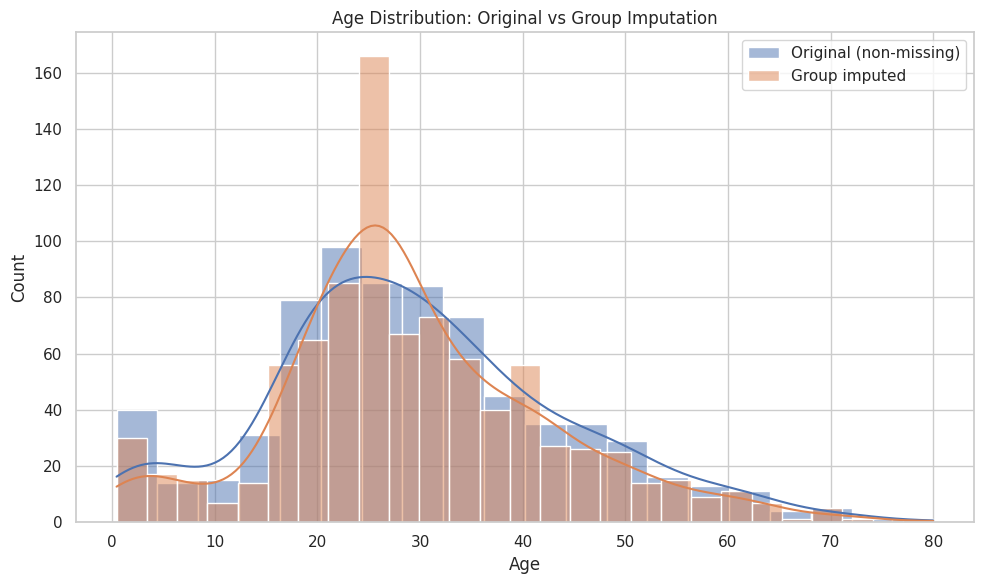

In [59]:
# Compare the original and group-imputed age distributions
plt.figure(figsize=(10, 6))

# Plot histograms
sns.histplot(titanic_df['Age'].dropna(), kde=True, label='Original (non-missing)', alpha=0.5)
sns.histplot(df_group_imputed['Age'], kde=True, label='Group imputed', alpha=0.5)

plt.title('Age Distribution: Original vs Group Imputation')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.show()

---Back to the slides!---

# 6. Handling Mixed Data Types

Real-world data sets often contain a mix of numerical and categorical variables. Let's implement a complete missing data handling strategy for the Titanic data set.

In [62]:
# Create a copy of the original data set
df_complete_strategy = titanic_df.copy()

# Examine the data types
df_complete_strategy.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [60]:
# Create a copy of the original data set
df_with_indicators = titanic_df.copy()

# Add missing indicators for 'Age' and 'Cabin'
df_with_indicators['Age_missing'] = df_with_indicators['Age'].isnull().astype(int)
df_with_indicators['Cabin_missing'] = df_with_indicators['Cabin'].isnull().astype(int)

# Impute missing values
df_with_indicators['Age'] = df_with_indicators['Age'].fillna(df_with_indicators['Age'].mean())
df_with_indicators['Cabin'] = df_with_indicators['Cabin'].fillna('Unknown')

# Check the result
df_with_indicators[['Age', 'Age_missing', 'Cabin', 'Cabin_missing']].head(10)

,Age,Age_missing,Cabin,Cabin_missing
0,22.000000,0,Unknown,1
1,38.000000,0,C85,0
2,26.000000,0,Unknown,1
3,35.000000,0,C123,0
4,35.000000,0,Unknown,1
5,29.699118,1,Unknown,1
6,54.000000,0,E46,0
7,2.000000,0,Unknown,1
8,27.000000,0,Unknown,1
9,14.000000,0,Unknown,1


In [63]:
# Implement a complete missing data strategy
# 1. Drop columns with too many missing values
df_complete_strategy = df_complete_strategy.drop(columns=['Cabin'])

# 2. Handle numerical variables
numeric_columns = ['Age', 'Fare']
# Group passengers by class and gender for more accurate imputation
for col in numeric_columns:
    # Calculate group means
    group_means = df_complete_strategy.groupby(['Pclass', 'Sex'])[col].transform('mean')
    # Impute missing values with group means
    df_complete_strategy[col] = df_complete_strategy[col].fillna(group_means)
    # For any remaining missing values (rare groups), use overall mean
    df_complete_strategy[col] = df_complete_strategy[col].fillna(df_complete_strategy[col].mean())

# 3. Handle categorical variables
# Impute 'Embarked' with mode
df_complete_strategy['Embarked'] = df_complete_strategy['Embarked'].fillna(df_complete_strategy['Embarked'].mode()[0])

# 4. Check if there are any missing values left
print("Missing values after complete strategy:")
print(df_complete_strategy.isnull().sum())

Missing values after complete strategy:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# 7. Best Practices and Conclusion

Let's summarize best practices for handling missing data in Python:

### Best Practices for Handling Missing Data

1. **Understand the data**: Always start by exploring the extent and patterns of missingness.
2. **Consider the missingness mechanism**: Is the data MCAR, MAR, or MNAR? This influences your choice of handling method.
3. **Document your approach**: Keep track of how you handled missing data for transparency and reproducibility.
4. **Use appropriate methods for different variables**: Consider the type and importance of each variable.
5. **Create missing indicators**: For key variables, create indicator variables to preserve information about missingness.
6. **Compare different approaches**: Evaluate the impact of different methods on your analysis or model.
7. **Consider domain knowledge**: Incorporate subject matter expertise in your imputation strategy.
8. **Be cautious with deletion methods**: Only use deletion when data is MCAR or the amount of missingness is very small.
9. **Conduct sensitivity analysis**: Test how sensitive your conclusions are to different missing data handling approaches.

# 8. Now You Try

1. Load a data set of your choice (you can use any that we have seen so far, or one of your own) and identify missing values.
2. Visualize the pattern of missingness using `missingno`.
3. Implement at least three different imputation methods.
4. Evaluate and compare the methods based on their effect on your analysis results or model performance.
5. Develop a comprehensive strategy for handling missing data in the data set, taking into account the variable types and missingness patterns.

# 9. Conclusion

In this notebook, we've explored various techniques for handling missing data in Python using pandas and other libraries. We've learned how to identify, visualize, and address missing values using deletion and imputation methods. Remember that there's no one-size-fits-all approach to handling missing data, and the best strategy depends on the specific characteristics of your data set and the goals of your analysis.